# ScraperFC #
SCraperFC is a Python Library made a couple of years ago that makes extracting data from popular football stat websites easy and free.

Usually you would install ScraperFC through PIP but my poor computer has like 3 instances of python on it and gets confused. I had to do this to make sure it installed properly.

In [1]:
import sys
import subprocess

# This identifies the exact python.exe your notebook is currently using
python = sys.executable

# This runs the install command via the system
subprocess.check_call([python, '-m', 'pip', 'install', 'ScraperFC'])

print("Installation successful!")

Installation successful!


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ScraperFC as sfc
import time
import difflib

c:\Users\danch\anaconda3\envs\cs418env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

# Capology #
Capology is a website that provides comprehensive estimates of professional football player salaries and club financial data. We are going to use it to gather the player salary data.

Data is taken directedly from the html files through ScraperFC and turned into a dataframe. Unneccessary or redundant columns (country of origin, weekly pay, etc.) are removed, the yearly pay column is converted from a string (since it is taken from an html file) to a double for calculations, and the column labels are renamed for clairity.

Data is taken from the 5 previous seasons (to get a wide variety of data but avoid having to add inflation calculations). Each season is processed separatedly, has a season column added, and then added to one large final dataframe.

In [3]:
# Import functions
from scraper_fuctions import scrape_capology_multiple_seasons

# Define seasons to scrape
seasons_to_scrape = ['2024-25', '2023-24', '2022-23', '2021-22', '2020-21']

# Run scraper
capology_df = scrape_capology_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if capology_df is not None:
    display(capology_df.head())
    print(f"\nTotal entries in dataset: {len(capology_df)}")

Scraping data for the 2024-25 season...
Changed currency to eur.
  -> Success! 770 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2023-24 season...
Changed currency to eur.
  -> Success! 610 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2022-23 season...
Changed currency to eur.
  -> Success! 593 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2021-22 season...
Changed currency to eur.
  -> Success! 562 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2020-21 season...
Changed currency to eur.
  -> Success! 593 players scraped.
  -> Sleeping for 10 seconds...

Scraping complete! Master DataFrame created.


,Season,Player,Salary (EUR),Position,Age,Club
0,2024-25,Erling Haaland,31626269.0,F,24,Manchester City
1,2024-25,Kevin De Bruyne,24096205.0,F,33,Manchester City
2,2024-25,Mohamed Salah,24096205.0,F,32,Liverpool
3,2024-25,Virgil van Dijk,21084179.0,D,33,Liverpool
4,2024-25,Casemiro,21084179.0,M,32,Manchester United



Total entries in dataset: 3128


# SofaScore #
SofaScore is a premier live score and sports analytics platform that provides real-time data, detailed statistics, and unique player ratings. We are going to use it to gather specific player data, it has 110 unique stats.

Data is taken from the SofaScore API through ScraperFC and turned into a dataframe. Unneccessary or redundant columns (team, player_id, etc.) are removed and its season is reformated to match the syntax that Capology used (to make merging easier later).

Data is taken from the 5 previous seasons (to match Capology data). Each season is processed separatedly, has a season column added, and then added to one large final dataframe. After all seasons have combined, any columns with null values are removed (to account for different stats being recorded each season and prevent conclusion that ignore a season).

In [6]:
# Import functions
from scraper_fuctions import scrape_sofascore_multiple_seasons

# Run scraper
sofa_df = scrape_sofascore_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if sofa_df is not None:
    display(sofa_df[['Season', 'Player', 'rating']].head())
    print(f"\nTotal entries in dataset: {len(sofa_df)}")

Scraping Sofascore data for the 2024-25 season (API format: 24/25)...
Running
  -> Success! 562 players scraped. Columns: 111
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2023-24 season (API format: 23/24)...
  -> Success! 570 players scraped. Columns: 112
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2022-23 season (API format: 22/23)...
  -> Success! 554 players scraped. Columns: 110
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2021-22 season (API format: 21/22)...
  -> Success! 538 players scraped. Columns: 107
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2020-21 season (API format: 20/21)...
  -> Success! 524 players scraped. Columns: 106
  -> Sleeping for 10 seconds...

Scraping complete! Sofascore Master DataFrame created.


,Season,Player,rating
0,2024-25,Neto,7.85
1,2024-25,Mohamed Salah,7.78
2,2024-25,Cole Palmer,7.63
3,2024-25,Mark Travers,7.62
4,2024-25,Bruno Fernandes,7.62



Total entries in dataset: 2748


In [7]:
print(sofa_df.columns.tolist())

['Season', 'accurateChippedPasses', 'accurateCrosses', 'accurateCrossesPercentage', 'accurateFinalThirdPasses', 'accurateLongBalls', 'accurateLongBallsPercentage', 'accurateOppositionHalfPasses', 'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage', 'aerialDuelsWon', 'aerialDuelsWonPercentage', 'aerialLost', 'appearances', 'assists', 'attemptPenaltyMiss', 'attemptPenaltyPost', 'attemptPenaltyTarget', 'bigChancesCreated', 'bigChancesMissed', 'blockedShots', 'cleanSheet', 'clearances', 'countRating', 'crossesNotClaimed', 'directRedCards', 'dispossessed', 'dribbledPast', 'duelLost', 'errorLeadToGoal', 'errorLeadToShot', 'fouls', 'freeKickGoal', 'goalConversionPercentage', 'goals', 'goalsAssistsSum', 'goalsConceded', 'goalsConcededInsideTheBox', 'goalsConcededOutsideTheBox', 'goalsFromInsideTheBox', 'goalsFromOutsideTheBox', 'groundDuelsWon', 'groundDuelsWonPercentage', 'headedGoals', 'highClaims', 'hitWoodwork', 'inaccuratePasses', 'interceptions', 'keyPasses', 'leftFootG

# Merging the Dataframes #
The two data frames are combined on player name and season.

Difflab is a python library that is used to match up the player names between the two different dataframe (to account for naming differeneces like accents or capitalization). Seasons titles are already normalized across the dataframes.

In [10]:
# Import merge function
from merge_functions import build_master_dataset

# Build the final dataset
seasons = ['2024-25']  # or multiple: ['2022-23', '2023-24', '2024-25']
master_df = scrape_capology_multiple_seasons(seasons)
combined_df = build_master_dataset(master_df, sofa_df)

# Display the results
print(f"\nTotal Rows: {len(combined_df)}")
print(f"Total Columns: {len(combined_df.columns)}")
display(combined_df.head())

Scraping data for the 2024-25 season...
Changed currency to eur.
  -> Success! 770 players scraped.
  -> Sleeping for 10 seconds...

Scraping complete! Master DataFrame created.
Standardizing Capology player names to match Sofascore...
Executing Final Inner Merge...
Merge Complete!

Total Rows: 542
Total Columns: 106


,Season,Player,Salary (EUR),Position,Age,Club,accurateChippedPasses,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,...,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalRating,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,2024-25,Erling Haaland,31626269.0,F,24,Manchester City,5,1,33.33,125,...,3,273,105,375,225.3,108,4,696,13,2
1,2024-25,Kevin De Bruyne,24096205.0,F,33,Manchester City,39,38,26.21,473,...,53,975,198,1028,207.3,57,6,1425,18,2
2,2024-25,Mohamed Salah,24096205.0,F,32,Liverpool,55,17,21.52,471,...,52,1017,217,1155,295.7,130,13,1864,39,1
3,2024-25,Virgil van Dijk,21084179.0,D,33,Liverpool,107,0,0.00,395,...,276,1264,1659,2922,269.2,27,5,3346,13,5
4,2024-25,Casemiro,21084179.0,M,32,Manchester United,69,8,40.00,193,...,91,532,448,960,172.2,32,2,1298,19,5


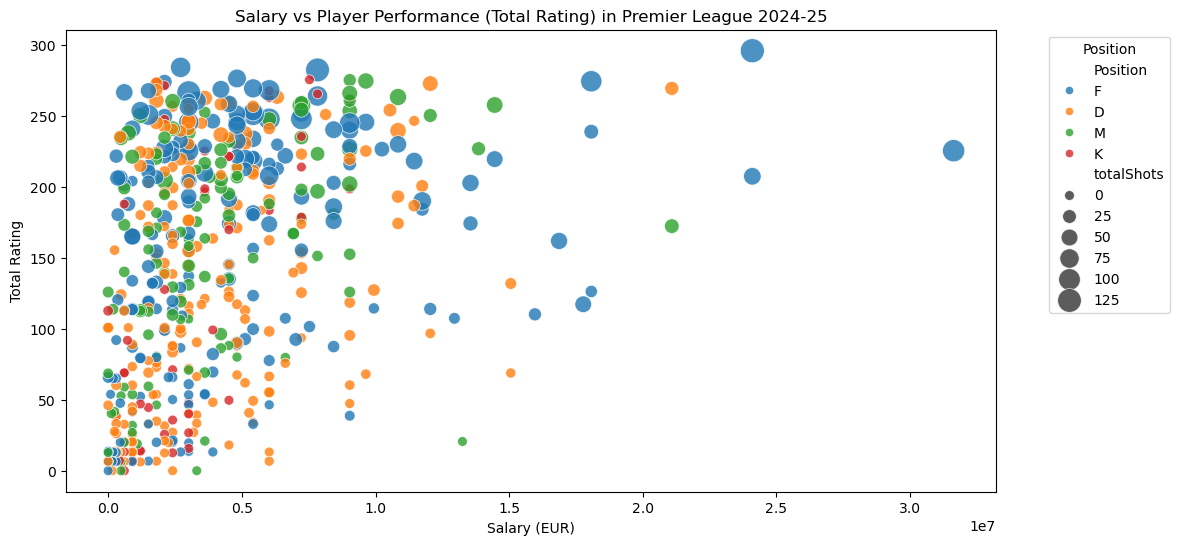

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(12,6))
sns.scatterplot(
    data=combined_df,
    x="Salary (EUR)",
    y="totalRating",
    hue="Position",
    size="totalShots",  # optional: highlights offensive contribution
    sizes=(50, 300),
    palette="tab10",
    alpha=0.8
)
plt.title("Salary vs Player Performance (Total Rating) in Premier League 2024-25")
plt.xlabel("Salary (EUR)")
plt.ylabel("Total Rating")
plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Visualization and insights #
Positions
    - Forwards tend to dominate the high-salaries, with the highest average of shots taken. For a team to have better season performances having lots of goals will give you better results.
    - Defenders and Midfielders are more so in the mid-range despite their ratings, showing that their performance doesn't correlate to higher salaries.

# Salary vs Performance relationship #
Performance seems to inconsistent as there are clusters of high rated players with salaries that of lower rated players. This might suggest that many players are undervalued. Also the pay is heavily influenced by the position.

# Shots vs Performance #
Bubble size represents totalShots. Larger bubbles are seen most buy higher rated strikers, which makes sense because players that shoot more given that they score a few times, contribute more to total rating.
Some players with ratings around 150 but have larger bubbles may suggest that they have high activity but very inconsistent.


# Reflection # 

What is hardest part of the project that you’ve encountered so far?  

o What are your initial insights?  

o Are there any concrete results you can show at this point? If not, why not?  

o Going forward, what are the current biggest problems you’re facing?  

o Do you think you are on track with your project? If not, what parts do you
need to dedicate more time to?  

o Given your initial exploration of the data, is it worth proceeding with your
project, why? If not, how are you going to change your project and why do
you think it’s better than your current results?  



# Next Steps #
What you plan to accomplish in the next month and how you plan to
evaluate whether your project achieved the goals you set for it.